<a href="https://colab.research.google.com/github/Haricharan-Venkatesh/exploratory-data-analysis-project/blob/main/dataset_preprocessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Using the absolute path to load the data
df = pd.read_csv('/content/games.csv')

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (20058, 16)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


None

In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate game IDs:", df["id"].duplicated().sum())


Rows: 20058
Columns: 16


,dtype
id,object
rated,bool
created_at,float64
last_move_at,float64
turns,int64
victory_status,object
winner,object
increment_code,object
white_id,object
white_rating,int64


,missing
id,0
rated,0
created_at,0
last_move_at,0
turns,0
victory_status,0
winner,0
increment_code,0
white_id,0
white_rating,0


Exact duplicate rows: 429
Duplicate game IDs: 945


In [7]:
# Remove exact duplicate rows first.
clean = df.drop_duplicates().copy()

# The same game ID can still occur multiple times.
# Sort by creation time and retain one record per game ID.
clean = (
    clean.sort_values("created_at")
         .drop_duplicates("id", keep="first")
         .reset_index(drop=True)
)

print("Raw rows:", len(df))
print("After exact deduplication:", len(df.drop_duplicates()))
print("After one-row-per-game-ID cleaning:", len(clean))
print("Missing cells after cleaning:", clean.isna().sum().sum())


Raw rows: 20058
After exact deduplication: 19629
After one-row-per-game-ID cleaning: 19113
Missing cells after cleaning: 0


In [8]:
def extract_game_features(row):
    moves = str(row["moves"]).split()
    n = len(moves)

    white_moves = moves[0::2]
    black_moves = moves[1::2]

    def stats(ms):
        if not ms:
            return dict(move_count=0, avg_san_length=0, capture_count=0,
                        check_count=0, mate_count=0, castle_count=0,
                        promotion_count=0, tactical_move_rate=0)

        capture = sum("x" in m for m in ms)
        check = sum("+" in m for m in ms)
        mate = sum("#" in m for m in ms)
        castle = sum(m in ("O-O", "O-O-O", "0-0", "0-0-0") for m in ms)
        promotion = sum("=" in m for m in ms)

        return {
            "move_count": len(ms),
            "avg_san_length": np.mean([len(m) for m in ms]),
            "capture_count": capture,
            "check_count": check,
            "mate_count": mate,
            "castle_count": castle,
            "promotion_count": promotion,
            "tactical_move_rate": (capture + check + mate) / len(ms)
        }

    ws, bs = stats(white_moves), stats(black_moves)
    duration_sec = max(0, (row["last_move_at"] - row["created_at"]) / 1000)
    opening_tokens = moves[:min(n, 20)]

    return pd.Series({
        "num_plies": n,
        "num_full_moves": math.ceil(n / 2),
        "game_duration_sec": duration_sec,
        "avg_sec_per_ply": duration_sec / n if n else np.nan,
        "rating_avg": (row["white_rating"] + row["black_rating"]) / 2,
        "rating_gap": abs(row["white_rating"] - row["black_rating"]),

        "white_move_count": ws["move_count"],
        "black_move_count": bs["move_count"],
        "white_avg_san_length": ws["avg_san_length"],
        "black_avg_san_length": bs["avg_san_length"],

        "white_capture_count": ws["capture_count"],
        "black_capture_count": bs["capture_count"],
        "white_check_count": ws["check_count"],
        "black_check_count": bs["check_count"],
        "white_mate_count": ws["mate_count"],
        "black_mate_count": bs["mate_count"],
        "white_castle_count": ws["castle_count"],
        "black_castle_count": bs["castle_count"],
        "white_promotion_count": ws["promotion_count"],
        "black_promotion_count": bs["promotion_count"],

        "white_tactical_move_rate": ws["tactical_move_rate"],
        "black_tactical_move_rate": bs["tactical_move_rate"],

        "overall_capture_rate": (
            ws["capture_count"] + bs["capture_count"]
        ) / n if n else np.nan,

        "overall_check_rate": (
            ws["check_count"] + bs["check_count"]
        ) / n if n else np.nan,

        "overall_tactical_move_rate": (
            ws["capture_count"] + bs["capture_count"] +
            ws["check_count"] + bs["check_count"] +
            ws["mate_count"] + bs["mate_count"]
        ) / n if n else np.nan,

        "opening_capture_count_first10_moves": sum("x" in m for m in opening_tokens),
        "opening_check_count_first10_moves": sum(("+" in m or "#" in m) for m in opening_tokens),
        "opening_ratio": row["opening_ply"] / n if n else np.nan,
    })

features = clean.apply(extract_game_features, axis=1)
featured = pd.concat([clean, features], axis=1)

display(featured.head())
print("Featured shape:", featured.shape)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,white_promotion_count,black_promotion_count,white_tactical_move_rate,black_tactical_move_rate,overall_capture_rate,overall_check_rate,overall_tactical_move_rate,opening_capture_count_first10_moves,opening_check_count_first10_moves,opening_ratio
0,hmdl0w8w,False,1.376772e+12,1.376772e+12,19,resign,white,12+8,julito,899,...,0.0,0.0,0.700000,0.000000,0.157895,0.210526,0.368421,3.0,4.0,0.210526
1,6trard8c,True,1.376772e+12,1.376772e+12,43,mate,white,7+15,kiii,1500,...,0.0,0.0,0.409091,0.333333,0.279070,0.069767,0.372093,3.0,2.0,0.139535
2,2hf0bf3b,True,1.376930e+12,1.376931e+12,27,resign,white,10+20,goldenfork,1381,...,0.0,0.0,0.285714,0.230769,0.222222,0.037037,0.259259,3.0,1.0,0.370370
3,63x6m6fx,False,1.376933e+12,1.376934e+12,84,resign,black,10+8,kiii,1170,...,1.0,1.0,0.523810,0.357143,0.226190,0.214286,0.440476,0.0,2.0,0.047619
4,rk7l19ti,True,1.376946e+12,1.376947e+12,51,mate,white,20+15,kiii,1348,...,0.0,0.0,0.461538,0.160000,0.215686,0.078431,0.313725,2.0,1.0,0.039216


Featured shape: (19113, 44)


In [9]:
os.makedirs("output", exist_ok=True)

clean.to_csv("output/cleaned_games.csv", index=False)
featured.to_csv("output/featured_games.csv", index=False)

print("Saved:")
print("output/cleaned_games.csv")
print("output/featured_games.csv")


Saved:
output/cleaned_games.csv
output/featured_games.csv


In [10]:
display(clean["winner"].value_counts().to_frame("games"))
display(clean["victory_status"].value_counts().to_frame("games"))
display(clean["rated"].value_counts().rename({True: "Rated", False: "Unrated"}).to_frame("games"))


,games
winner,
white,9545
black,8680
draw,888


,games
victory_status,
resign,10695
mate,5974
outoftime,1598
draw,846


,games
rated,
Rated,15467
Unrated,3646


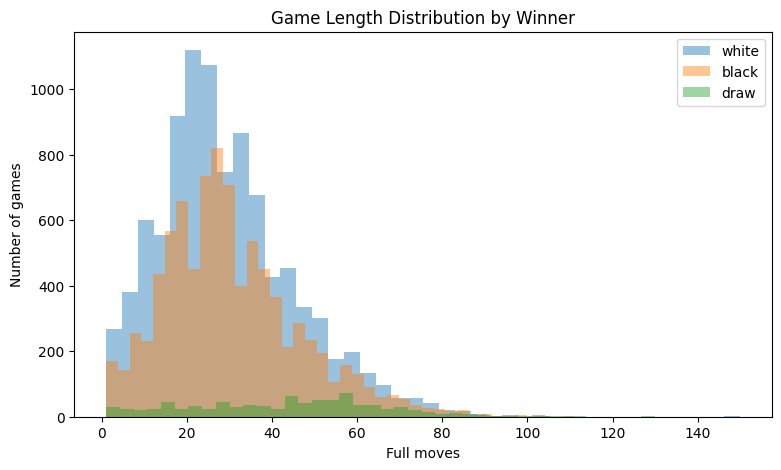

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

for label in ["white", "black", "draw"]:
    values = featured.loc[
        featured["winner"] == label, "num_full_moves"
    ].clip(upper=150)

    ax.hist(values, bins=40, alpha=0.45, label=label)

ax.set_title("Game Length Distribution by Winner")
ax.set_xlabel("Full moves")
ax.set_ylabel("Number of games")
ax.legend()
plt.show()


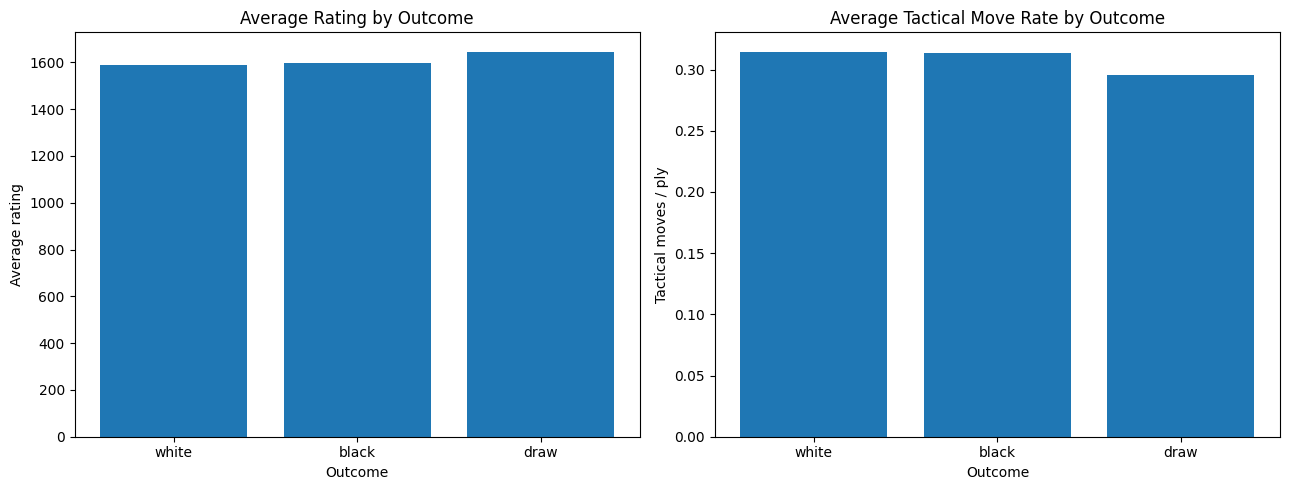

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rating_means = (
    featured.groupby("winner")["rating_avg"]
    .mean()
    .reindex(["white", "black", "draw"])
)

tactical_means = (
    featured.groupby("winner")["overall_tactical_move_rate"]
    .mean()
    .reindex(["white", "black", "draw"])
)

axes[0].bar(rating_means.index, rating_means.values)
axes[0].set_title("Average Rating by Outcome")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Average rating")

axes[1].bar(tactical_means.index, tactical_means.values)
axes[1].set_title("Average Tactical Move Rate by Outcome")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Tactical moves / ply")

plt.tight_layout()
plt.show()


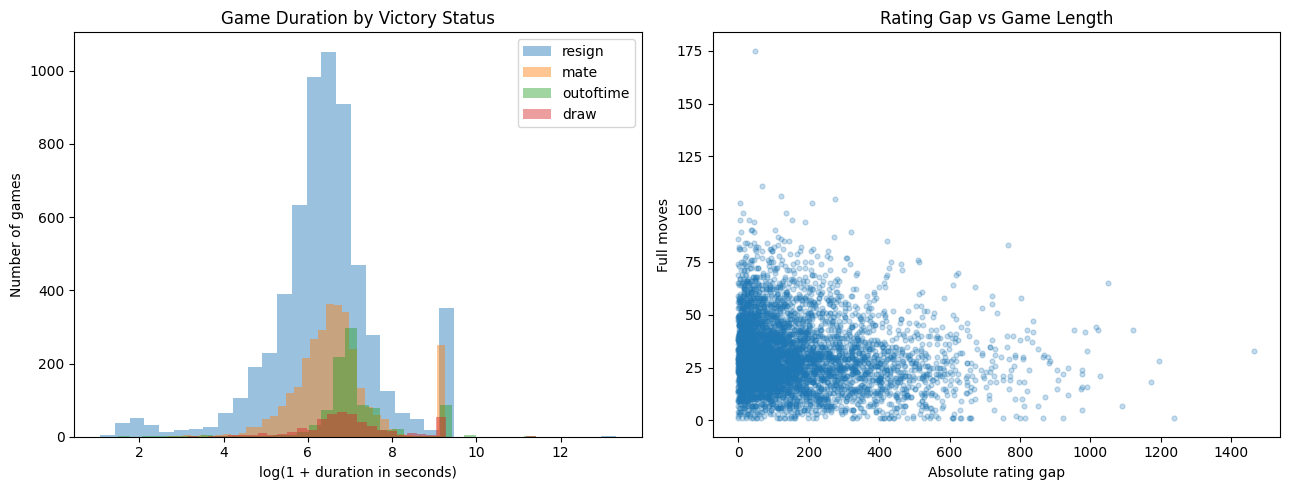

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for status in ["resign", "mate", "outoftime", "draw"]:
    values = featured.loc[
        featured["victory_status"] == status, "game_duration_sec"
    ]
    values = values[values > 0]

    if len(values):
        axes[0].hist(np.log1p(values), bins=35, alpha=0.45, label=status)

axes[0].set_title("Game Duration by Victory Status")
axes[0].set_xlabel("log(1 + duration in seconds)")
axes[0].set_ylabel("Number of games")
axes[0].legend()

sample = featured.sample(min(5000, len(featured)), random_state=42)
axes[1].scatter(
    sample["rating_gap"],
    sample["num_full_moves"],
    alpha=0.25,
    s=12
)
axes[1].set_title("Rating Gap vs Game Length")
axes[1].set_xlabel("Absolute rating gap")
axes[1].set_ylabel("Full moves")

plt.tight_layout()
plt.show()


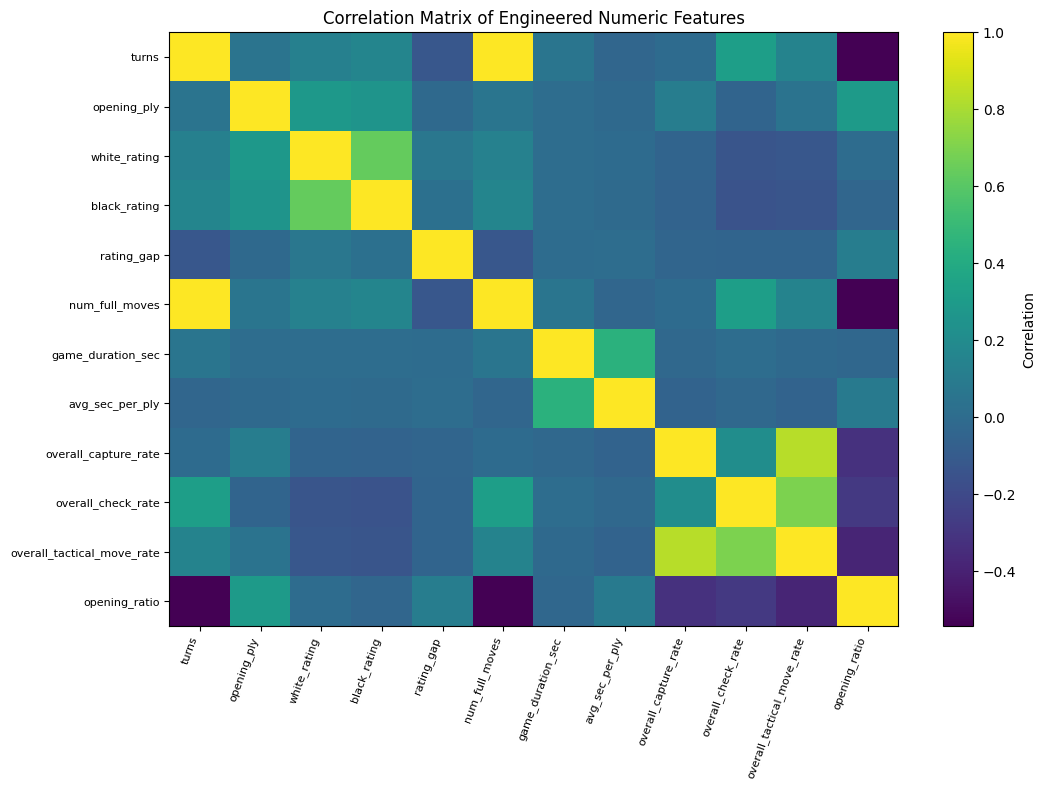

In [14]:
num_cols = [
    "turns", "opening_ply", "white_rating", "black_rating",
    "rating_gap", "num_full_moves", "game_duration_sec",
    "avg_sec_per_ply", "overall_capture_rate",
    "overall_check_rate", "overall_tactical_move_rate", "opening_ratio"
]

corr = featured[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=70, ha="right", fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of Engineered Numeric Features")
plt.tight_layout()
plt.show()
